In [1]:
import numpy
import matplotlib.pyplot as plt

print("Hello tian")

Hello tian


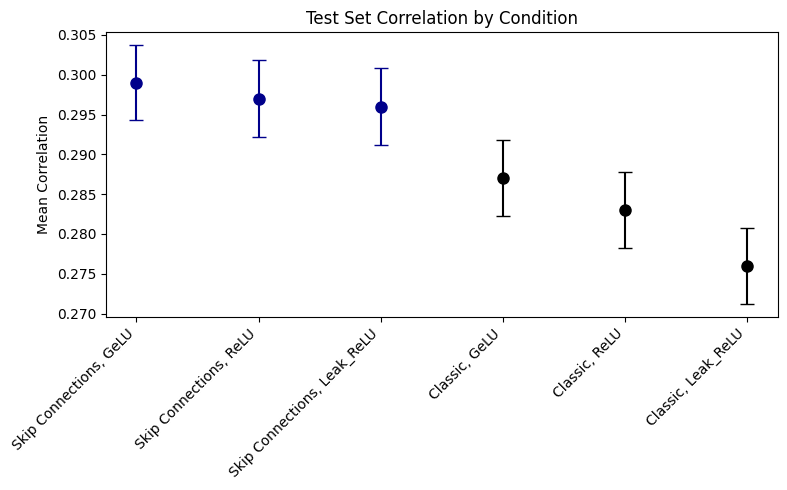

In [3]:

means = [0.299, 0.297, 0.296, 0.287, 0.283, 0.276]  
sterrs = [0.0047, 0.0048361, 0.004848, 0.0047681, 0.0047513, 0.0048031]  # replace with your sterr values
labels = ['Skip Connections, GeLU', 'Skip Connections, ReLU', 'Skip Connections, Leak_ReLU', 'Classic, GeLU', 'Classic, ReLU', 'Classic, Leak_ReLU']  # replace with your labels

colors = ['darkblue', 'darkblue', 'darkblue', 'black', 'black', 'black']

fig, ax = plt.subplots(figsize=(8, 5))

for i, (mean, sterr, color, label) in enumerate(zip(means, sterrs, colors, labels)):
    ax.errorbar(i, mean, yerr=sterr, fmt='o', color=color, 
                capsize=5, markersize=8, label=label)

ax.set_xticks(range(6))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Mean Correlation')
ax.set_title('Test Set Correlation by Condition')
plt.tight_layout()
plt.savefig('correlation_plot.png', dpi=150)
plt.show()

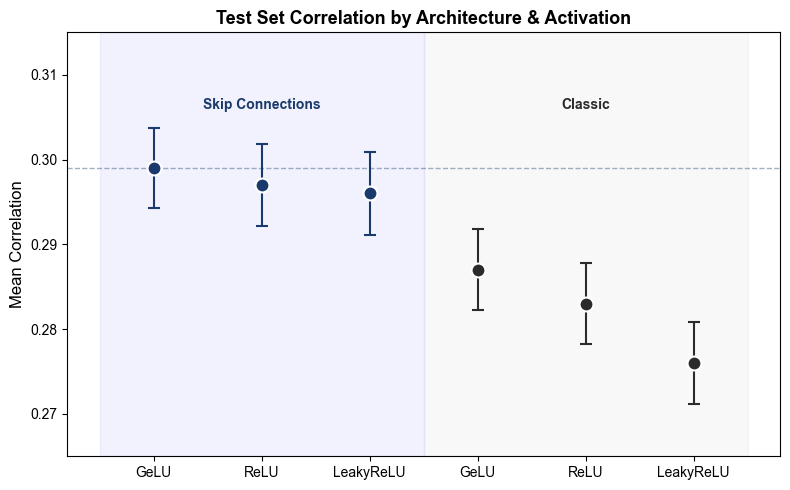

In [4]:
import matplotlib.pyplot as plt
import numpy as np

means = [0.299, 0.297, 0.296, 0.287, 0.283, 0.276]  
sterrs = [0.0047, 0.0048361, 0.004848, 0.0047681, 0.0047513, 0.0048031]
labels = ['Skip+GeLU', 'Skip+ReLU', 'Skip+LeakyReLU', 'Classic+GeLU', 'Classic+ReLU', 'Classic+LeakyReLU']

colors = ['#1a3a6b', '#1a3a6b', '#1a3a6b', '#2b2b2b', '#2b2b2b', '#2b2b2b']

fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use('seaborn-v0_8-whitegrid')

for i, (mean, sterr, color, label) in enumerate(zip(means, sterrs, colors, labels)):
    ax.errorbar(i, mean, yerr=sterr, fmt='o', color=color,
                capsize=4, capthick=1.5, elinewidth=1.5,
                markersize=10, markeredgewidth=1.5,
                markeredgecolor='white', label=label)

# shade the two groups
ax.axvspan(-0.5, 2.5, alpha=0.05, color='blue', label='_nolegend_')
ax.axvspan(2.5, 5.5, alpha=0.05, color='gray', label='_nolegend_')

# group labels at top
ax.text(1, 0.306, 'Skip Connections', ha='center', fontsize=10, color='#1a3a6b', fontweight='bold')
ax.text(4, 0.306, 'Classic', ha='center', fontsize=10, color='#2b2b2b', fontweight='bold')

ax.set_xticks(range(6))
ax.set_xticklabels(['GeLU', 'ReLU', 'LeakyReLU', 'GeLU', 'ReLU', 'LeakyReLU'], fontsize=10)
ax.set_ylabel('Mean Correlation', fontsize=12)
ax.set_title('Test Set Correlation by Architecture & Activation', fontsize=13, fontweight='bold')
ax.set_ylim(0.265, 0.315)

# dashed line at best score
ax.axhline(y=0.299, color='#1a3a6b', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('correlation_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import pickle
import pandas as pd

with open('/Users/cyue/Desktop/TianWork/Stanford25-26/CS229/stsbench-main/dataset/dorsal_stream_neuron_table.pickle', 'rb') as f:
    neuron_table = pickle.load(f)

print(type(neuron_table))
if hasattr(neuron_table, 'head'):
    print(neuron_table.head())
    print(neuron_table.columns.tolist())
else:
    print(neuron_table)

<class 'pandas.DataFrame'>
   neuron_id  session_id  neuron_uid x_coord_neu y_coord_neu  \
0          1       82824           0        11.0        20.0   
1          4       82824           1        11.0         0.0   
2          8       82824           2       114.0         0.0   
3         32       82824           3        11.0       160.0   
4         33       82824           4        11.0       180.0   

                                      template_times  \
0  [0.0, 0.03333333333333333, 0.06666666666666667...   
1  [0.0, 0.03333333333333333, 0.06666666666666667...   
2  [0.0, 0.03333333333333333, 0.06666666666666667...   
3  [0.0, 0.03333333333333333, 0.06666666666666667...   
4  [0.0, 0.03333333333333333, 0.06666666666666667...   

                                            template template_trough_to_peak  \
0  [-0.03260965, -0.052709486, -0.06782218, -0.07...                   200.0   
1  [0.25014895, 0.25289863, 0.26891083, 0.2699676...              433.333333   
2  [0.05147

In [8]:
import pickle
import pandas as pd
import numpy as np

# how many of each type
print(neuron_table['template_type'].value_counts())

# randomly select x neurons from a specific type
def get_random_neurons(neuron_table, template_type, x, seed=42):
    np.random.seed(seed)
    indices = neuron_table[neuron_table['template_type'] == template_type].index.tolist()
    selected = np.random.choice(indices, min(x, len(indices)), replace=False)
    print(f"Selected {len(selected)} neurons of type '{template_type}'")
    return selected.tolist()

# usage - replace 'fast_spiking' with your actual type name from value_counts output
fast_spiking_neurons = get_random_neurons(neuron_table, 'fast_spiking', 20)
broad_spiking_neurons = get_random_neurons(neuron_table, 'broad_spiking', 20)

print("Fast spiking indices:", fast_spiking_neurons)
print("Broad spiking indices:", broad_spiking_neurons)

template_type
AS    899
RS    885
FS    460
Name: count, dtype: int64
Selected 0 neurons of type 'fast_spiking'
Selected 0 neurons of type 'broad_spiking'
Fast spiking indices: []
Broad spiking indices: []


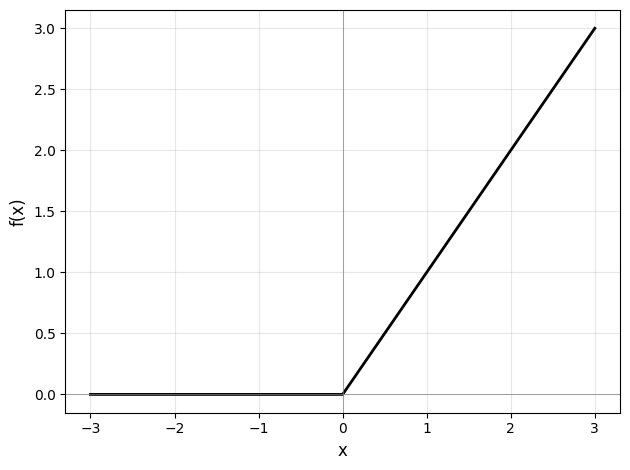

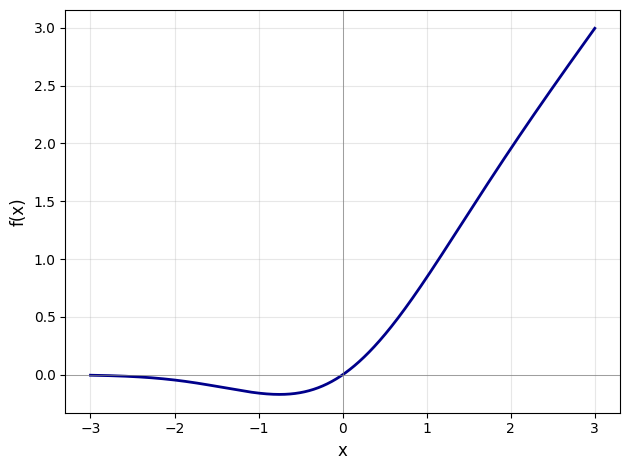

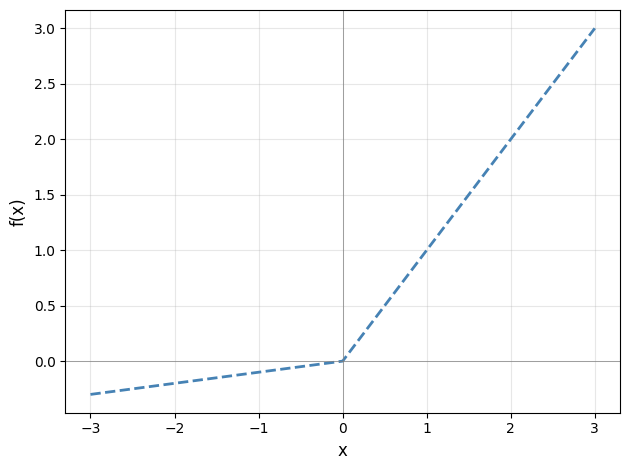

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

x = torch.linspace(-3, 3, 1000)

relu = F.relu(x).numpy()
gelu = F.gelu(x).numpy()
leaky_relu = F.leaky_relu(x, negative_slope=0.1).numpy()
x = x.numpy()

# plt.figure(figsize=(8, 5))
plt.plot(x, relu, label='ReLU', color='black', linewidth=2)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)

# plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.plot(x, gelu, label='GELU', color='darkblue', linewidth=2)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)

# plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.plot(x, leaky_relu, label='Leaky ReLU', color='steelblue', linewidth=2, linestyle='--')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)

# plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()